# **Reproduction: Topological Loss for Image Segmentation (Clough et al., 2022)**

The authors use the following libraries:
1. PyTorch for CNNs
2. TopLayer for persistent homology calculations
3. Gudhi for barcode visualisations

## **Imports**

In [ ]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    try:
        from topologylayer.nn import LevelSetLayer2D, TopKBarcodeLengths
        import gudhi
    except Exception:
        !rm -rf TopologyLayer
        !git clone https://github.com/bruel-gabrielsson/TopologyLayer.git
        !sed -i 's/AT_CHECK/TORCH_CHECK/g' TopologyLayer/topologylayer/functional/persistence/*
        with open('TopologyLayer/setup.py', 'r') as f:
            code = f.read()
        code = code.replace("extra = {'cxx': ['-std=c++14']}", "extra = {'cxx': ['-std=c++17', '-fpermissive', '-w']}")
        with open('TopologyLayer/setup.py', 'w') as f:
            f.write(code)
        !pip install -e ./TopologyLayer --no-build-isolation
        !pip install gudhi
        sys.path.append('/content/TopologyLayer')
        from topologylayer.nn import LevelSetLayer2D, TopKBarcodeLengths
        import gudhi
else:
    from topologylayer.nn import LevelSetLayer2D, TopKBarcodeLengths
    import gudhi

import copy
import numpy as np
import random
import matplotlib.pyplot as plt
import concurrent.futures

random_seed = 42

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(random_seed)

## **Experiment 1 (MNIST)**

In [2]:
%%writefile loss_functions.py
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from topologylayer.nn import TopKBarcodeLengths
import gudhi


def dice_loss(y_pred, y_true):
    """ Standard Dice Loss: 1 - 2|X ∩ Y| / (|X| + |Y|) """
    intersection = (y_pred * y_true).sum()
    total = y_pred.sum() + y_true.sum()
    return 1.0 - (2.0 * intersection + 1e-8) / (total + 1e-8)


def compute_topological_loss_single(Z_single, target_betti, dgminfo, max_k=10, device="cuda"):
    a = dgminfo(Z_single.cpu())
    
    # Dim 0
    L0 = (TopKBarcodeLengths(dim=0, k=max_k)(a) ** 2).sum().to(device)

    # Dim 1
    target_holes = target_betti[1] if isinstance(target_betti, (tuple, list)) else target_betti.get(1, 0)
    dim_1_sq_bars = TopKBarcodeLengths(dim=1, k=max_k)(a) ** 2
    bar_signs = torch.ones(max_k, device=device)
    bar_signs[:target_holes] = -1.0
    L1 = (dim_1_sq_bars.to(device) * bar_signs).sum()

    return L0 + L1


def compute_topological_loss_single_gudhi(Z_single, target_betti, dgminfo=None, max_k=10, device=None):
    Z = Z_single.squeeze()
    dev = Z.device if device is None else device
    
    neg_Z_np = (-Z).detach().cpu().numpy().flatten()
    
    cubical = gudhi.CubicalComplex(dimensions=list(Z.shape), top_dimensional_cells=neg_Z_np)
    cubical.compute_persistence()
    pairs = cubical.cofaces_of_persistence_pairs()
    
    Z_flat = Z.view(-1)
    
    def extract_top_k(pair_array):
        if pair_array is None or len(pair_array) == 0 or pair_array.ndim == 1:
            return torch.zeros(max_k, device=dev)
            
        b_idx = torch.tensor(pair_array[:, 0] % Z_flat.numel(), device=dev, dtype=torch.long)
        d_idx = torch.tensor(pair_array[:, 1] % Z_flat.numel(), device=dev, dtype=torch.long)
        
        lengths = Z_flat[b_idx] - Z_flat[d_idx]
        lengths, _ = torch.sort(lengths, descending=True)
        
        if len(lengths) < max_k:
            padding = torch.zeros(max_k - len(lengths), device=dev, dtype=lengths.dtype)
            return torch.cat([lengths, padding])
        return lengths[:max_k]

    p0 = pairs[0][0] if len(pairs) > 0 and len(pairs[0]) > 0 else None
    p1 = pairs[1][0] if len(pairs) > 1 and len(pairs[1]) > 0 else None
    
    L0_bars = extract_top_k(p0)
    L1_bars = extract_top_k(p1)
    
    # Dim 0 Loss
    L0 = (L0_bars ** 2).sum()
    
    # Dim 1 Loss
    target_holes = target_betti[1] if isinstance(target_betti, (tuple, list)) else target_betti.get(1, 0)
    bar_signs = torch.ones(max_k, device=dev)
    bar_signs[:target_holes] = -1.0
    
    L1 = ((L1_bars ** 2) * bar_signs).sum()
    
    return L0 + L1


def post_processing_framework(
    model: nn.Module,
    X_test_noise: torch.Tensor,
    X_test_clean: torch.Tensor,
    Y_test_labels: list,
    H_dict: dict,
    dgminfo_layer: nn.Module,
    num_iter_topo: int = 30,
    lr: float = 1e-6,
    lambda_topo: float = 0.02,
    max_k: int = 10,
    verbose: bool = True,
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
):
    L_sqdiff_weight = 1 / lambda_topo

    l2_loss_fn = nn.MSELoss()
    mse_before_list, mse_after_list = [], []
    y_before_all, y_after_all = [], []

    if verbose:
        print(f"Running Post-Processing on {len(X_test_noise)} Samples on {device}", flush=True)

    model = model.to(device)
    model_topo = copy.deepcopy(model).to(device)
    original_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    for i in range(len(X_test_noise)):
        model_topo.load_state_dict(original_state)
        optimizer = torch.optim.Adam(model_topo.parameters(), lr=lr)
        sample_betti = H_dict[Y_test_labels[i]]

        model.eval()
        with torch.no_grad():
            x_in = X_test_noise[i:i+1].to(device)
            y_before = model(x_in).cpu().detach()
            original_output = y_before.clone().to(device)

        mse_before_list.append(l2_loss_fn(y_before, X_test_clean[i:i+1].cpu()).item())
        y_before_all.append(y_before)

        model_topo.train()
        for _ in range(num_iter_topo):
            optimizer.zero_grad()
            Z = model_topo(x_in)
            Z_64 = F.interpolate(Z, size=(64, 64), mode="bilinear", align_corners=False)
            
            L_topo = compute_topological_loss_single(Z_64, sample_betti, dgminfo_layer, max_k=max_k, device=device)
            L_sqdiff = l2_loss_fn(original_output, Z) * L_sqdiff_weight
            
            (L_topo + L_sqdiff).backward()
            optimizer.step()

        model_topo.eval()
        with torch.no_grad():
            y_after = model_topo(x_in).cpu().detach()

        mse_after_list.append(l2_loss_fn(y_after, X_test_clean[i:i+1].cpu()).item())
        y_after_all.append(y_after)

        if verbose and ((i + 1) % 10 == 0 or i == 0):
            print(f"[{device}] Progress: {i + 1}/{len(X_test_noise)} samples done", flush=True)

    Y_before_tensor = torch.cat(y_before_all, dim=0)
    Y_after_tensor = torch.cat(y_after_all, dim=0)

    return mse_before_list, mse_after_list, Y_before_tensor, Y_after_tensor


# def semi_supervised_framework(
#     model: nn.Module,
#     X_labeled_noise: torch.Tensor,
#     X_labeled_clean: torch.Tensor,
#     X_unlabeled_noise: torch.Tensor,
#     Y_unlabeled_labels: list,
#     H_dict: dict,
#     dgminfo_layer: nn.Module,
#     warmup_epochs: int = 100,
#     semisupervised_epochs: int = 100,
#     lr: float = 1e-4,
#     lambda_topo: float = 0.01,
#     max_k: int = 10,
#     device: str = "cuda"
# ):
#     model = model.to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#     print(f"Stage 1: Supervised Warmup ({warmup_epochs} Epochs)", flush=True)
#     labeled_dataset = TensorDataset(X_labeled_noise, X_labeled_clean)
#     labeled_loader = DataLoader(labeled_dataset, batch_size=len(X_labeled_noise), shuffle=True)

#     for epoch in range(1, warmup_epochs + 1):
#         model.train()
#         for x_b, y_b in labeled_loader:
#             x_b, y_b = x_b.to(device), y_b.to(device)
#             optimizer.zero_grad()
#             preds = model(x_b)
#             loss = sum(dice_loss(preds[b:b+1], y_b[b:b+1]) for b in range(preds.size(0)))
#             loss.backward()
#             optimizer.step()

#     print(f"Stage 2: Joint Semi-Supervised Training ({semisupervised_epochs} Epochs)", flush=True)
    
#     x_l = X_labeled_noise.to(device)
#     y_l = X_labeled_clean.to(device)
#     x_u = X_unlabeled_noise.to(device)

#     for epoch in range(1, semisupervised_epochs + 1):
#         model.train()
#         optimizer.zero_grad()

#         preds_l = model(x_l)
#         loss_dice = sum(dice_loss(preds_l[b:b+1], y_l[b:b+1]) for b in range(preds_l.size(0)))

#         preds_u = model(x_u)
#         loss_topo = sum(
#             compute_topological_loss_single(
#                 preds_u[b:b+1], H_dict[Y_unlabeled_labels[b]], dgminfo_layer, max_k=max_k, device=device
#             )
#             for b in range(preds_u.size(0))
#         )

#         total_loss = loss_dice + lambda_topo * loss_topo
#         total_loss.backward()
#         optimizer.step()

#         if epoch % 100 == 0 or epoch == 1:
#             print(f"Epoch {epoch}/{semisupervised_epochs} | Sum Dice: {loss_dice.item():.4f} | Sum Topo: {loss_topo.item():.4f} | Total: {total_loss.item():.4f}", flush=True)

#     return model

Overwriting loss_functions.py


In [3]:
%%writefile neural_nets.py
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2
from topologylayer.nn import LevelSetLayer2D
import copy

from loss_functions import post_processing_framework

random_seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def corrupt_fourier(img, m, seed=42):
    np.random.seed(seed)
    img = np.squeeze(img)
    fft_shifted = np.fft.fftshift(np.fft.fft2(img))
    h, w = img.shape
    h_idx = np.random.choice(h, size=m, replace=False)
    v_idx = np.random.choice(w, size=m, replace=False)
    corrupted_fft = fft_shifted.copy()
    corrupted_fft[h_idx, :] = 0
    corrupted_fft[:, v_idx] = 0
    corrupted = np.abs(np.fft.ifft2(corrupted_fft))
    return corrupted / corrupted.max()


def conv_block(in_channels, out_channels, num_convs=3):
    layers = []
    for i in range(num_convs):
        layers.append(
            nn.Conv2d(
                in_channels if i == 0 else out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1
            )
        )
        layers.append(nn.ReLU())
    return nn.Sequential(*layers)


class Segmenter_Unet(nn.Module):
    def __init__(self, img_dim, num_filters=16):
        super().__init__()
        self.img_dim = img_dim
        self.num_filters = num_filters
        self.conv1 = conv_block(1, num_filters, num_convs=2)
        self.down1 = nn.Conv2d(num_filters, num_filters * 2, kernel_size=3, stride=2, padding=1)
        self.conv2 = conv_block(num_filters * 2, num_filters * 2, num_convs=2)
        self.down2 = nn.Conv2d(num_filters * 2, num_filters * 4, kernel_size=3, stride=2, padding=1)
        self.conv3 = conv_block(num_filters * 4, num_filters * 4, num_convs=3)
        self.up1 = conv_block(num_filters * 6, num_filters * 2, num_convs=3)
        self.up2 = conv_block(num_filters * 3, num_filters, num_convs=3)
        self.conv_final = nn.Conv2d(num_filters, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        x = F.relu(self.down1(x1))
        x2 = self.conv2(x)
        x = F.relu(self.down2(x2))
        x = self.conv3(x)
        x = torch.cat([F.interpolate(x, scale_factor=2), x2], dim=1)
        x = self.up1(x)
        x = torch.cat([F.interpolate(x, scale_factor=2), x1], dim=1)
        x = self.up2(x)
        x = torch.sigmoid(self.conv_final(x))
        return x


class MNIST_classifier(nn.Module):
    def __init__(self, img_dim, num_filters=16, num_classes=10):
        super(MNIST_classifier, self).__init__()
        self.img_dim = img_dim
        self.num_filters = num_filters
        self.num_classes = num_classes

        self.conv1_1 = nn.Conv2d(1, self.num_filters, 3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(self.num_filters, self.num_filters,   3, stride=1, padding=1)
        self.conv1_3 = nn.Conv2d(self.num_filters, self.num_filters*2, 3, stride=2, padding=1)

        self.conv2_1 = nn.Conv2d(self.num_filters*2, self.num_filters*2, 3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(self.num_filters*2, self.num_filters*2, 3, stride=1, padding=1)
        self.conv2_3 = nn.Conv2d(self.num_filters*2, self.num_filters*4, 3, stride=2, padding=1)

        self.conv3_1 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)
        self.conv3_2 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)
        self.conv3_3 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)

        self.low_res_img_dim = self.img_dim // 4
        self.final_conv_num_filters = self.num_filters*4
        self.fc_1 = nn.Linear(self.low_res_img_dim**2 * self.final_conv_num_filters, self.final_conv_num_filters)
        self.fc_2 = nn.Linear(self.final_conv_num_filters, self.final_conv_num_filters)
        self.fc_3 = nn.Linear(self.final_conv_num_filters, self.final_conv_num_filters)

        self.fc_final = nn.Linear(self.final_conv_num_filters, self.num_classes)

    def forward(self, x):
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = F.relu(self.conv1_3(x))
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = F.relu(self.conv2_3(x))
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))

        x = x.view(-1, self.low_res_img_dim**2 * self.final_conv_num_filters)
        x = F.relu(self.fc_1(x))
        x = F.relu(self.fc_2(x))
        x = F.relu(self.fc_3(x))
        x = self.fc_final(x)
        return x


def train_initial_model(
    model: nn.Module,
    X_train_noise: torch.Tensor,
    X_train_clean: torch.Tensor,
    X_val: torch.Tensor = None,
    Y_val: torch.Tensor = None,
    batch_size: int = 64,
    num_epochs: int = 100,
    lr: float = 1e-3,
    patience: int = 5,
    seed: int = 42,
    verbose: bool = True,
    device: str = "cuda"
):
    set_seed(seed)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_dataset_pairs = TensorDataset(X_train_noise, X_train_clean.float())
    train_loader = DataLoader(train_dataset_pairs, batch_size=batch_size, shuffle=True)

    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    best_val_loss = 1

    if verbose:
        print(f"Starting Training on {device} (Max Epochs: {num_epochs})", flush=True)

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_bce_loss = 0.0
        
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = F.binary_cross_entropy(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_bce_loss += loss.item() * x_batch.size(0)

        avg_loss = train_bce_loss / len(train_dataset_pairs)

        # EARLY STOPPING LOGIC (fine-tune training)
        if X_val is not None and Y_val is not None:
            model.eval()
            with torch.no_grad():
                val_loss = F.binary_cross_entropy(model(X_val[:128].to(device)), Y_val[:128].to(device)).item()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            if verbose and (epoch == 1 or epoch % 5 == 0):
                print(f"  Epoch [{epoch:03d}/{num_epochs:03d}] Loss: {avg_loss:.4f} | Val loss: {val_loss:.4f} (Best: {best_val_loss:.4f})", flush=True)

            if patience_counter >= patience:
                if verbose:
                    print(f" early stopping triggered at Epoch {epoch}! Restoring best weights (Val Dice: {best_val_loss:.4f}).", flush=True)
                model.load_state_dict(best_weights)
                break

    if verbose:
        print(f"Supervised Training Complete on {device}.", flush=True)
    return model


def train_classifier(model, optimizer, X, Y, X_test, Y_test,
                      batch_size=50, num_epochs=1, verbose=False, device="cpu"):
    set_seed(random_seed)

    model.train()
    N = X.shape[0]
    num_batches = N // batch_size
    
    for e in range(num_epochs):
        if verbose and ((e + 1) % 10 == 0 or e == 0):
            print(f"Starting epoch {e + 1}/{num_epochs}")

        train_loss = 0.
        batch_indices = np.arange(N, dtype=int)
        np.random.shuffle(batch_indices)

        for b in range(num_batches):
            this_batch_indices = batch_indices[b*batch_size:(b+1)*batch_size]
            X_batch = X[this_batch_indices].to(device)
            Y_batch = Y[this_batch_indices].to(device)

            optimizer.zero_grad()
            predict_batch = model(X_batch)
            ce_loss = nn.CrossEntropyLoss()(predict_batch, Y_batch)
            train_loss += ce_loss.item()
            ce_loss.backward()
            optimizer.step()

    if verbose:
        test_acc, _ = evaluate_accuracy(model, X_test, Y_test, device)
        print(f"Classifier Test Accuracy: {test_acc:.2f}%")

    return model


def evaluate_accuracy(model, X_data, Y_data, device):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        if not isinstance(Y_data, torch.Tensor):
            Y_data = torch.tensor(Y_data, dtype=torch.long)
        X_dev = X_data.to(device)
        Y_dev = Y_data.to(device)
        logits = model(X_dev)
        preds = logits.argmax(dim=1)
        is_correct = (preds == Y_dev).cpu()
        acc = is_correct.float().mean().item() * 100.0
    return acc, is_correct


def run_one_iteration(itr_args):
    itr, N_train, N_test, m, random_seed, device_str, classifier = itr_args
    is_first = True

    set_seed(random_seed + itr)
    device = torch.device(device_str)

    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

    X_test = torch.stack([test_dataset[i][0] for i in range(N_test)])
    Y_test = [test_dataset[i][1] for i in range(N_test)]

    X_test_noise = torch.stack([
        torch.tensor(corrupt_fourier(img, m=m, seed=random_seed + i), dtype=torch.float32).unsqueeze(0)
        for i, img in enumerate(X_test)
    ])

    H_dict = {
        0: (1, 1), 1: (1, 0), 2: (1, 0), 3: (1, 0), 4: (1, 0),
        5: (1, 0), 6: (1, 1), 7: (1, 0), 8: (1, 2), 9: (1, 1)
    }
    dgminfo = LevelSetLayer2D(size=(28, 28), sublevel=False, maxdim=1)

    start_idx = itr * N_train
    end_idx = start_idx + N_train

    X_train = torch.stack([train_dataset[i][0] for i in range(start_idx, end_idx)])
    X_train_noise = torch.stack([
        torch.tensor(corrupt_fourier(img, m=m, seed=random_seed + start_idx + i), dtype=torch.float32).unsqueeze(0)
        for i, img in enumerate(X_train)
    ])

    torch.manual_seed(random_seed + itr)
    model = Segmenter_Unet(img_dim=28)
    model = model.to(device)

    learning_rate = 1e-4
    batch_size = N_train
    epochs = 1000

    model = train_initial_model(
        model=model,
        X_train_noise=X_train_noise,
        X_train_clean=X_train,
        batch_size=batch_size,
        num_epochs=epochs,
        lr=learning_rate,
        seed=random_seed + itr,
        verbose=is_first,
        device=device
    )

    avg_before, avg_after, Y_before, Y_after = post_processing_framework(
        model=model,
        X_test_noise=X_test_noise,
        X_test_clean=X_test,
        Y_test_labels=Y_test,
        H_dict=H_dict,
        dgminfo_layer=dgminfo,
        verbose=is_first,
        device=device
    )

    _, correct_before = evaluate_accuracy(classifier, Y_before, Y_test, device)
    _, correct_after = evaluate_accuracy(classifier, Y_after, Y_test, device)

    return avg_before, avg_after, correct_before, correct_after

Overwriting neural_nets.py


In [ ]:
from neural_nets import corrupt_fourier, MNIST_classifier, run_one_iteration, train_classifier

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(random_seed)
classifier = MNIST_classifier(img_dim=28).to(device)
classifier_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

# N = 10 000 training pairs (idx 10 000 - 20 000 train, all 10 000 test)
X_classifier_train = torch.stack([train[i][0] for i in range(10000, 20000)])
Y_classifier_train = torch.tensor([train[i][1] for i in range(10000, 20000)], dtype=torch.long)

X_classifier_test = torch.stack([test[i][0] for i in range(10000)])
Y_classifier_test = torch.tensor([test[i][1] for i in range(10000)], dtype=torch.long)

if os.path.exists('./MNIST_classifier.pt'):
    print("Importing Classifier Model", flush=True)
    classifier = MNIST_classifier(img_dim=28).to(device)
    classifier.load_state_dict(torch.load('./MNIST_classifier.pt'))
else:
    print("Training Classifier Model", flush=True)
    classifier = train_classifier(
        classifier,
        classifier_optimizer,
        X_classifier_train,
        Y_classifier_train,
        X_classifier_test,
        Y_classifier_test,
        batch_size=64,
        num_epochs=50,
        verbose=True,
        device=device
    )
    torch.cuda.empty_cache()
    torch.save(classifier.state_dict(), './MNIST_classifier.pt')

N_train = 100
N_test = 1000
m_grid = [2, 4, 6, 8, 10, 12]

num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0

print(f"Detected {num_gpus} CUDA GPUs for parallel execution.", flush=True)

tasks = []
for idx, m in enumerate(m_grid):
    dev_str = f"cuda:{idx % num_gpus}" if num_gpus > 0 else "cpu"
    tasks.append((0, N_train, N_test, m, random_seed, dev_str, classifier)) # remove 0 (old for itr)?

if num_gpus > 1:
    ctx = torch.multiprocessing.get_context('spawn')
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_gpus, mp_context=ctx) as executor:
        results = list(executor.map(run_one_iteration, tasks))
else:
    results = [run_one_iteration(t) for t in tasks]

for m, r in zip(m_grid, results):
    mse_before, mse_after = r[0], r[1]
    correct_before, correct_after = r[2], r[3]

    N = N_test
    _, p_value_mse = stats.wilcoxon(mse_before, mse_after, alternative='two-sided')

    b = ((correct_before == 1) & (correct_after == 0)).sum().item()
    c = ((correct_before == 0) & (correct_after == 1)).sum().item()
    
    chi2 = (abs(b - c) - 1.0) ** 2 / (b + c) if (b + c) > 0 else 0.0
    p_value_acc = stats.chi2.sf(chi2, df=1)

    mse_mean_before = np.mean(mse_before)
    mse_mean_after = np.mean(mse_after)
    std_before = np.std(mse_before, ddof=1)
    std_after = np.std(mse_after, ddof=1)

    mse_interval_before = (mse_mean_before - std_before, mse_mean_before + std_before)
    mse_interval_after = (mse_mean_after - std_after, mse_mean_after + std_after)

    acc_mean_before = correct_before.float().mean().item() * 100.0
    acc_mean_after = correct_after.float().mean().item() * 100.0

    p_before = acc_mean_before / 100.0
    acc_std_error_before = np.sqrt(p_before * (1.0 - p_before)) * 100.0

    p_after = acc_mean_after / 100.0
    acc_std_error_after = np.sqrt(p_after * (1.0 - p_after)) * 100.0

    acc_interval_before = (acc_mean_before - acc_std_error_before, acc_mean_before + acc_std_error_before)
    acc_interval_after = (acc_mean_after - acc_std_error_after, acc_mean_after + acc_std_error_after)

    print(f"\n-------- Final Results for m={m} --------", flush=True)
    print(f"MSE BEFORE: {mse_mean_before:.4f}  |  Interval: ({mse_interval_before[0]:.4f}, {mse_interval_before[1]:.4f})")
    print(f"MSE AFTER:  {mse_mean_after:.4f}  |  Interval: ({mse_interval_after[0]:.4f}, {mse_interval_after[1]:.4f})")
    print(f"MSE Statistical Significance (Wilcoxon): {p_value_mse <= 0.05} (p-value: {p_value_mse:.4f})")
    print(f"ACC BEFORE: {acc_mean_before:.2f}%  |  Interval: ({acc_interval_before[0]:.2f}%, {acc_interval_before[1]:.2f}%)")
    print(f"ACC AFTER:  {acc_mean_after:.2f}%  |  Interval: ({acc_interval_after[0]:.2f}%, {acc_interval_after[1]:.2f}%)")
    print(f"ACC Statistical Significance (McNemar):  {p_value_acc <= 0.05} (p-value: {p_value_acc:.4f})")

## **Exploration**

In [ ]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Size of training set is {len(train_dataset)}")
print(f"Size of test set is {len(test_dataset)}")

N_train = 100
N_test = 1000

set_seed(random_seed)
train_idx = torch.randperm(10000)[:N_train]
test_idx = torch.randperm(10000)[:N_test]

X_train = torch.stack([train_dataset[i][0] for i in train_idx])
X_test = torch.stack([test_dataset[i][0] for i in test_idx])
Y_train = [train_dataset[i][1] for i in train_idx]
Y_test = [test_dataset[i][1] for i in test_idx]


print("Train digit counts (0-9):", torch.bincount(torch.tensor(Y_train)).tolist())
print("Test digit counts (0-9): ", torch.bincount(torch.tensor(Y_test)).tolist())

In [ ]:
digit_samples = {}
for idx in range(len(train_dataset)):
    image, label = train_dataset[idx]
    if label not in digit_samples:
        digit_samples[label] = (image, idx)
    if len(digit_samples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    image, idx = digit_samples[digit]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Digit: {digit}\n(Dataset Index: {idx})")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
indices = {
    '5': 0,
    '9': 4,
    '3': 7,
}

m_values = [4, 6, 8]  
digits = ['5', '9', '3']

fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for row, (digit_str, m) in enumerate(zip(digits, m_values)):
    idx = indices[digit_str]
    img_orig = train_dataset[idx][0].squeeze().numpy()
    img_corr = corrupt_fourier(img_orig, m=m)
    
    axes[row, 0].imshow(img_orig, cmap='gray')
    axes[row, 0].set_title(f"Original (Digit {digit_str})")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(img_corr, cmap='gray')
    axes[row, 1].set_title(f"Corrupted (m = {m})")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

## **Experiment 3**

[TRAIN] Successfully loaded 1902 slices into memory.
[TEST] Successfully loaded 1076 slices into memory.

[SUCCESS] Datasets loaded!
  X_train: torch.Size([1902, 1, 256, 256]) | Y_train: torch.Size([1902, 1, 256, 256])
  X_test : torch.Size([1076, 1, 256, 256])  | Y_test : torch.Size([1076, 1, 256, 256])
  test_betti[0]: (1, 1)


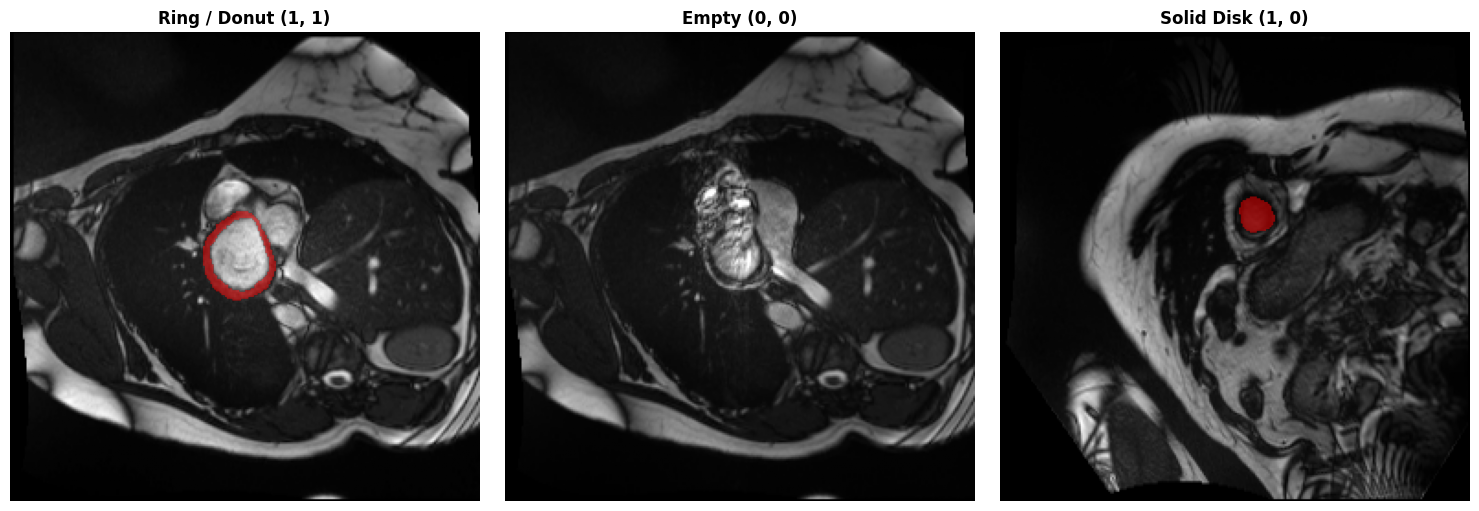

In [4]:
import os
import glob
import zipfile
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy import ndimage
from huggingface_hub import snapshot_download

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


def download_and_extract_acdc(download_dir="./acdc_data"):
    """Downloads and automatically extracts Images.zip and Masks.zip."""
    os.makedirs(download_dir, exist_ok=True)
    if not os.path.exists(os.path.join(download_dir, "Images.zip")):
        print(f"Downloading ACDC dataset to '{download_dir}'...")
        snapshot_download(repo_id="YongchengYAO/ACDC", repo_type="dataset", local_dir=download_dir)
        
    for z_name in ["Images.zip", "Masks.zip"]:
        z_path = os.path.join(download_dir, z_name)
        extracted_folder = os.path.join(download_dir, z_name.replace(".zip", ""))
        if os.path.exists(z_path) and not os.path.exists(extracted_folder):
            print(f"Unzipping {z_name}...")
            with zipfile.ZipFile(z_path, "r") as zip_ref:
                zip_ref.extractall(download_dir)


def get_betti_numbers(binary_mask):
    """Computes exact (beta_0, beta_1) numbers and topology category from a 2D mask."""
    if binary_mask.sum() == 0:
        return (0, 0), "Empty (0, 0)"
    
    _, num_cc = ndimage.label(binary_mask)
    inv_mask = 1 - binary_mask
    labeled_inv, num_inv = ndimage.label(inv_mask)
    bg_label = labeled_inv[0, 0]
    num_holes = max(0, num_inv - 1 if bg_label != 0 else num_inv)
    
    if num_cc == 1 and num_holes == 1:
        category = "Ring / Donut (1, 1)"
    elif num_cc == 1 and num_holes == 0:
        category = "Solid Disk (1, 0)"
    elif num_cc == 0:
        category = "Empty (0, 0)"
    else:
        category = f"Complex ({num_cc}, {num_holes})"
        
    return (num_cc, num_holes), category


class ACDC2DSliceDataset(Dataset):
    def __init__(self, data_dir="./acdc_data", split="train", target_size=(256, 256)):
        self.split = split
        self.slice_records = []  # Stores metadata (patient_id, frame_id, etc.)
        
        all_masks = sorted(glob.glob(os.path.join(data_dir, "**", "*_gt.nii.gz"), recursive=True))
        if len(all_masks) == 0:
            raise FileNotFoundError(f"No '_gt.nii.gz' files found in '{os.path.abspath(data_dir)}'.")
            
        x_list, y_list, self.betti_dict = [], [], {}
        global_idx = 0
        
        for mask_path in all_masks:
            patient_id = int(os.path.basename(mask_path).split('_')[0].replace('patient', ''))
            frame_id = os.path.basename(mask_path).replace("_gt.nii.gz", "")
            
            if (split == "train" and patient_id > 100) or (split == "test" and patient_id <= 100):
                continue
                
            img_path = mask_path.replace("Masks", "Images").replace("_gt.nii.gz", ".nii.gz")
            if not os.path.exists(img_path):
                img_path = mask_path.replace("_gt.nii.gz", ".nii.gz")
                if not os.path.exists(img_path): continue
                
            img_vol = nib.load(img_path).get_fdata().astype(np.float32)
            mask_vol = nib.load(mask_path).get_fdata().astype(np.int64)
            
            for s_idx in range(img_vol.shape[2]):
                img_slice = img_vol[:, :, s_idx]
                myo_mask = (mask_vol[:, :, s_idx] == 2).astype(np.float32)
                
                i_min, i_max = img_slice.min(), img_slice.max()
                if i_max > i_min: img_slice = (img_slice - i_min) / (i_max - i_min)
                
                img_t = F.interpolate(torch.tensor(img_slice).unsqueeze(0).unsqueeze(0), 
                                      size=target_size, mode="bilinear", align_corners=False).squeeze(0)
                mask_t = F.interpolate(torch.tensor(myo_mask).unsqueeze(0).unsqueeze(0), 
                                       size=target_size, mode="nearest").squeeze(0)
                
                x_list.append(img_t)
                y_list.append(mask_t)
                
                betti, category = get_betti_numbers(myo_mask)
                self.betti_dict[global_idx] = betti
                
                self.slice_records.append({
                    "idx": global_idx,
                    "patient_id": patient_id,
                    "frame_id": frame_id,
                    "slice_idx": s_idx,
                    "betti_prior": betti,
                    "category": category
                })
                global_idx += 1

        self.X = torch.stack(x_list, dim=0)
        self.Y = torch.stack(y_list, dim=0)
        print(f"[{split.upper()}] Successfully loaded {len(self.X)} slices into memory.")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "image": self.X[idx],
            "mask": self.Y[idx],
            "betti_prior": self.betti_dict[idx],
            "category": self.slice_records[idx]["category"]
        }

    def __len__(self):
        return len(self.X)


def visualize_betti_distributions(dataset):
    """Finds and visualizes 1 representative sample of each of the 3 possible Betti categories."""
    found_samples = {}
    for idx in range(len(dataset)):
        sample = dataset[idx]
        cat = sample["category"]
        if cat not in found_samples:
            found_samples[cat] = sample
        if len(found_samples) >= 3:
            break

    ordered_cats = ["Ring / Donut (1, 1)", "Empty (0, 0)", "Solid Disk (1, 0)"]
    display_samples = [found_samples[c] for c in ordered_cats if c in found_samples]

    fig, axes = plt.subplots(1, len(display_samples), figsize=(5 * len(display_samples), 5))
    if len(display_samples) == 1:
        axes = [axes]

    for i, sample in enumerate(display_samples):
        img = sample["image"].squeeze().numpy()
        mask = sample["mask"].squeeze().numpy()
        category = sample["category"]
        
        axes[i].imshow(img, cmap="gray")
        if mask.sum() > 0:
            axes[i].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.5)
            
        axes[i].set_title(f"{category}", fontsize=12, fontweight="bold")
        axes[i].axis("off")
        
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    download_and_extract_acdc("./acdc_data")
    
    train_dataset = ACDC2DSliceDataset(data_dir="./acdc_data", split="train")
    test_dataset  = ACDC2DSliceDataset(data_dir="./acdc_data", split="test")
    
    X_train, Y_train = train_dataset.X, train_dataset.Y
    X_test,  Y_test, test_betti = test_dataset.X, test_dataset.Y, test_dataset.betti_dict
    
    print("\n[SUCCESS] Datasets loaded!")
    print(f"  X_train: {X_train.shape} | Y_train: {Y_train.shape}")
    print(f"  X_test : {X_test.shape}  | Y_test : {Y_test.shape}")
    print(f"  test_betti[0]: {test_betti[0]}")
    
    visualize_betti_distributions(test_dataset)

In [7]:
from neural_nets import Segmenter_Unet, train_initial_model
from loss_functions import dice_loss

def run_one_iteration(itr_args):
    itr, N_train, N_test, m, random_seed, device_str, classifier = itr_args
    is_first = True

    set_seed(random_seed + itr)
    device = torch.device(device_str)

    X_train, Y_train = train_dataset.X, train_dataset.Y
    X_test,  Y_test,  test_betti  = test_dataset.X, test_dataset.Y, test_dataset.betti_dict

    model = Segmenter_Unet(img_dim=256)
    model = model.to(device)

    learning_rate = 1e-3
    batch_size = N_train
    epochs = 150

    model = train_initial_model(
        model, 
        X_train, 
        Y_train,
        X_val=X_test,
        Y_val=Y_test,
        batch_size=batch_size,
        num_epochs=epochs,
        lr=learning_rate,
        patience=15,
        device=device
    )

    model.eval()
    with torch.no_grad():
        preds_list = []
        for i in range(0, len(X_test), 64):
            x_batch = X_test[i : i + 64].to(device)
            p_batch = (model(x_batch) > 0.5).float().cpu()
            preds_list.append(p_batch)
            
        predictions = torch.cat(preds_list, dim=0).to(device)
        Y_test_dev = Y_test.to(device)
        
        mean_dice = 1.0 - dice_loss(predictions, Y_test_dev).item()
    if is_first:
        print(f"Test Mean Dice Score: {mean_dice:.4f}")

    save_path = "./acdc_unet_model.pt"
    torch.save(model.state_dict(), save_path)
    print(f"Model saved successfully to '{save_path}'!")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device}")
run_one_iteration([0, 128, 0, 0, 42, device, None])

: 

In [ ]:
import torch
from topologylayer.nn import LevelSetLayer2D
from loss_functions import post_processing_framework
from neural_nets import Segmenter_Unet

device = "cuda" if torch.cuda.is_available() else "cpu"

model = Segmenter_Unet(img_dim=256)
model.load_state_dict(torch.load("./acdc_unet_model.pt", map_location=device))
model = model.to(device)
model.eval()

train_dataset = ACDC2DSliceDataset(data_dir="./acdc_data", split="train")
test_dataset  = ACDC2DSliceDataset(data_dir="./acdc_data", split="test")

# TEMP CHANGES
X_test, Y_test = test_dataset.X[:100], test_dataset.Y[:100]
dgminfo = LevelSetLayer2D(size=(64, 64), sublevel=False, maxdim=1)
Y_test_labels = list(range(len(X_test)))

print("\n--- RUNNING TOPOLOGICAL POST-PROCESSING ---")
mse_before, mse_after, Y_before, Y_after = post_processing_framework(
    model=model,
    X_test_noise=X_test,
    X_test_clean=Y_test,
    Y_test_labels=Y_test_labels,
    H_dict=test_dataset.betti_dict,
    dgminfo_layer=dgminfo,
    num_iter_topo=50,
    lr=1e-6,
    lambda_topo=0.01,
    verbose=True,
    device=device
)

patient_volumes = {}
for rec in test_dataset.slice_records:
    pid = rec["patient_id"]
    phase = "ED" if "frame01" in rec["frame_id"] else "ES"
    key = (pid, phase)
    if key not in patient_volumes:
        patient_volumes[key] = []
    patient_volumes[key].append(rec["idx"])

def evaluate_3d_dice(Y_pred_tensor):
    ed_dices, es_dices = [], []
    for (pid, phase), slice_indices in patient_volumes.items():
        valid_indices = [idx for idx in slice_indices if idx < len(Y_pred_tensor)]
        vol_pred = (Y_pred_tensor[valid_indices].to(device) > 0.5).float()
        vol_true = Y_test[slice_indices].to(device)
        
        intersection_3d = (vol_pred * vol_true).sum()
        total_3d = vol_pred.sum() + vol_true.sum()
        dice_3d = ((2.0 * intersection_3d + 1e-8) / (total_3d + 1e-8)).item()
        
        if phase == "ED":
            ed_dices.append(dice_3d)
        else:
            es_dices.append(dice_3d)
            
    return sum(ed_dices) / len(ed_dices), sum(es_dices) / len(es_dices)

# 3D dice or other measure?
ed_before, es_before = evaluate_3d_dice(Y_before)
ed_after,  es_after  = evaluate_3d_dice(Y_after)

print("\n" + "="*60)
print("       CLOUGH ET AL. EVALUATION RESULTS (BEFORE vs AFTER)       ")
print("="*60)
print(f"End-Diastole (ED) 3D Mean Dice BEFORE : {ed_before:.4f}")
print(f"End-Diastole (ED) 3D Mean Dice AFTER  : {ed_after:.4f}  [Author Target: ~0.8994]")
print("-" * 60)
print(f"End-Systole  (ES) 3D Mean Dice BEFORE : {es_before:.4f}")
print(f"End-Systole  (ES) 3D Mean Dice AFTER  : {es_after:.4f}  [Author Target: ~0.9068]")
print("="*60)

In [6]:
import gc
gc.collect()
torch.cuda.empty_cache()